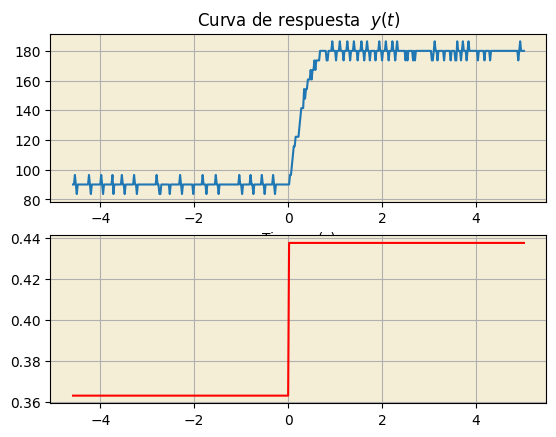

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


# El enlace "Raw" correcto para tu archivo
url = "https://raw.githubusercontent.com/nebisman/UNDCMotor/main/code/python_code/unmotor/datafiles/DCmotor_step_open_exp.csv"

df = pd.read_csv(url)



t = df["t"].tolist()
u = df["u"].tolist()
y = df["y"].tolist()
t= np.array(t[20:-1])
u= np.array(u[20:-1])
y= np.array(y[20:-1])
ind_step = np.diff(u).argmax() # es para detectar el indice del elemento donde ocurre el escalon
t = t-t[ind_step]

#graficamos la respuesta normalizada
fig, (yax, uax) = plt.subplots(nrows=2, ncols=1, )
yax.set_title(r'Curva de respuesta  ${y}(t)$')
yax.set_facecolor('#f4eed7')
yax.plot(t,y)
uax.set_facecolor('#f4eed7')
uax.plot(t,u,'red')
yax.grid(True)
uax.grid(True)
yax.set_xlabel("Tiempo (s)")
plt.show()



#### Paso 1


Encuentre $y_a$ gráficamente o como el promedio de $N$ puntos antes del cambio del escalón y $y_b$ como el promedio de los últimos $N$ puntos registrados en la respuesta al escalón.

Establezca el valor de $u_a$ y $u_b$.

In [5]:
# Paso 1



# este es el valor inicial del escalón antes del cambio
ua = u[ind_step]

# el último punto es el valor final del escalón
ub = u[-1]

# calculamos el valor inicial de temperatura antes del cambio en el escalón
# como el promedio de los 10 puntos antes del cambio
ya = np.mean(y[ind_step-10:ind_step+1])

# para el valor final de la temperatura tomamos un promedio de las 10 últimas valores
yb = np.mean(y[-10:])

# calculamos el cambio neto en el escalon
delta_u = ub - ua

# calculamos el cambio en el valor de estado estacionario de la salida
delta_y = yb - ya

print(ya, yb)
print(ua, ub)



90.00000763000001 180.00001526
0.36324835 0.4375011


#### Paso 2

Con los datos experimentales, encuentre y grafique la respuesta experimental normalizada $\overline{y}(t)$ del sistema por medio de siguiente ecuación:

 $$\overline{y}(t) = \frac{y(t)-y_a}{\Delta\,y}$$

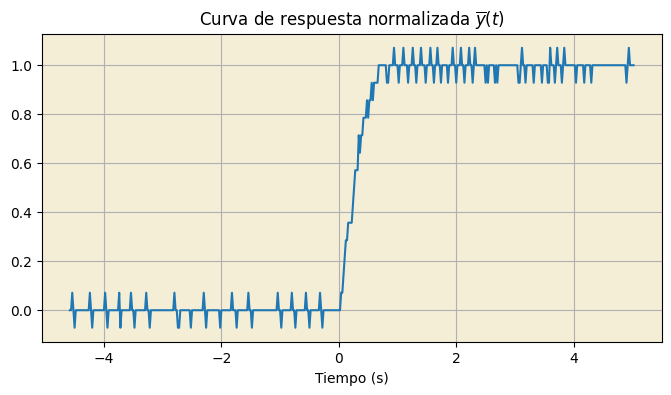

In [6]:
# paso 2
# calculamos la respuesta normalizada
y_norm = (y - ya) / delta_y

#graficamos la respuesta normalizada
fig, ax = plt.subplots(figsize=(8, 4))
ax.set_title(r'Curva de respuesta normalizada $\overline{y}(t)$')
ax.set_facecolor('#f4eed7')
ax.plot(t,y_norm)
ax.grid(True)
ax.set_xlabel("Tiempo (s)")
plt.show()



#### Paso 3

Encuentre por medio de interpolación numérica de la curva experimental los valores de tiempo $t_1, t_2$ en los cuales la respuesta experimental normalizada $\overline{y}(t)$ alcanza dos valores en la zona inicial de máxima pendiente de la curva, en la cual $\overline{y}(t)\leq 0.5$.

Por ejemplo, $\overline{y}_1=0.15$ y $\overline{y}_2=0.3$.

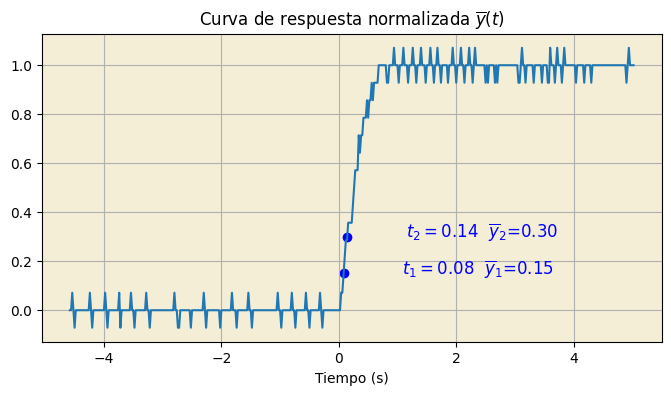

In [7]:
# Paso 3
# Definimos los puntos y1n=0.1, y y2n=0.3 y encontramos los tiempos en que se producen por interpolación numérica
y1n = 0.15
y2n = 0.3
t1 = np.interp(y1n, y_norm, t)
t2 = np.interp(y2n, y_norm, t)

#graficamos estos puntos en la figura anterior para ilustrar
fig, ax = plt.subplots(figsize=(8, 4))
ax.set_title(r'Curva de respuesta normalizada $\overline{y}(t)$')
ax.set_facecolor('#f4eed7')
ax.plot(t,y_norm)
ax.grid(True)
ax.set_xlabel("Tiempo (s)")
ax.scatter([t1, t2],[y1n,y2n],color='b')
ax.text( t1+1,y1n, f'$t_1=${t1:0.2f}  '+r'$\overline{y}_1$='+f'{y1n:0.2f}', fontsize=12, color='b')
ax.text( t2+1,y2n, f'$t_2=${t2:0.2f}  '+r'$\overline{y}_2$='+f'{y2n:0.2f}', fontsize=12, color='b')
plt.show()

#### Paso 4
Calcule $L$, $\tau$ y $\alpha$ usando las  siguientes ecuaciones:

$$\tau= \frac{t_2-t_1}{\ln(\frac{1-\overline{y}_1}{1-\overline{y}_2})}$$

$$L = t_1 + \tau \ln (1-\overline{y}_1)$$

$$\alpha =  \frac{\Delta\,y}{\Delta_u}$$




In [8]:
# Paso 4 calculamos los valores estimados de tao, L y alpha


tau = (t2-t1)/np.log((1-y1n)/(1-y2n))
L = np.max([0,t1 + tau * np.log(1-y1n)])
alpha = delta_y / delta_u

print(alpha, tau, L)

1212.0764231627786 0.31933087872230065 0.030102698110228664


### Comparación entre el modelo matemático y los datos.

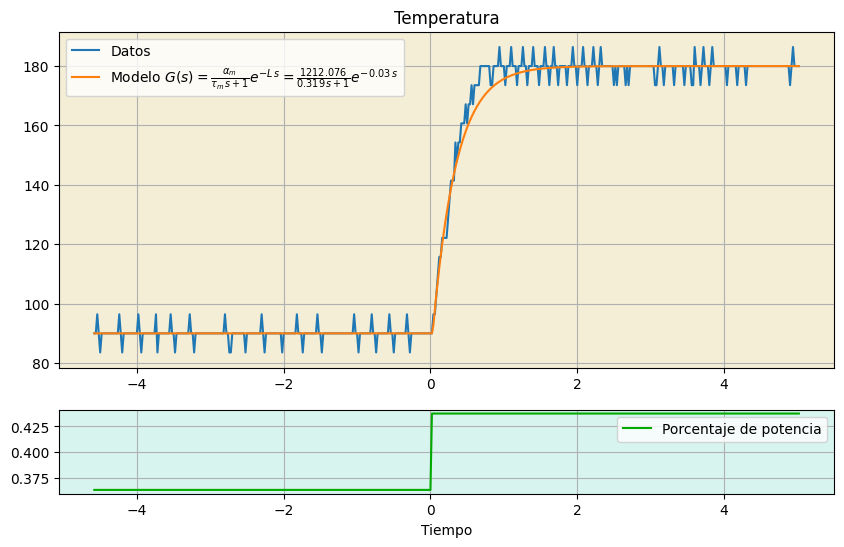

In [9]:
def compute_step_response(t, alpha, tau, L):
    # esta función calcula la respuesta al escalon con los parametros
    ym = []

    for ti in t:
        yi = alpha * delta_u * (1 - np.exp(-np.max([0, ti-L]) / tau)) + ya
        ym.append(yi)
    return ym


# calculamos la respuesta del modelo
ymodel = compute_step_response(t, alpha, tau, L)

# ahora graficamos la salida comparar los resultados
fig, (ay, au) = plt.subplots(2, 1, figsize=(10, 6),height_ratios=[4, 1])
ay.plot(t, y, t, ymodel)
ay.grid(True)
ay.set_title('Temperatura')
ay.set_facecolor('#f4eed7')
ay.legend(["Datos", r"Modelo $G(s)= \frac{\alpha_m}{\tau_m\,s + 1} e^{-L\,s} = \frac{%0.3f }{%0.3f\,s+1}e^{-%0.2f\,s}$" %(alpha, tau, L)])


# En este gráfico está la entrada escalón
au.plot(t, u, label='% de potencia de entrada', color="#00aa00")
au.set_xlabel("Tiempo")
au.set_facecolor('#d7f4ee')
au.grid(True)
au.legend(["Porcentaje de potencia"])
plt.show()